EDA - GERMAN CREDIT

# 1. Load dataset

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from ucimlrepo import fetch_ucirepo

In [2]:
# Load German Credit dataset trực tiếp từ UCI ML Repository (id=144)
german_credit = fetch_ucirepo(id=144)

X = german_credit.data.features.copy()
y = german_credit.data.targets.copy()

# ghép target
if isinstance(y, pd.DataFrame):
    y_series = y.iloc[:, 0]
else:
    y_series = pd.Series(y, name='Class')

df = X.copy()
df['Class'] = y_series.values

# chuẩn hóa tên cột theo đúng thứ tự chuẩn của German Credit (Statlog)
columns = [
    'Status', 'Duration', 'History', 'Purpose', 'Amount', 'Savings',
    'Employment', 'InstallmentRate', 'PersonalStatus', 'OtherDebtors',
    'ResidenceSince', 'Property', 'Age', 'OtherPlans', 'Housing',
    'ExistingCredits', 'Job', 'Liable', 'Telephone', 'ForeignWorker', 'Class'
 ]

if df.shape[1] == len(columns):
    df.columns = columns
else:
    print(f"Cảnh báo: số cột hiện tại = {df.shape[1]}, không khớp {len(columns)}. Giữ nguyên tên cột gốc.")

target_col = 'Class'

print(f"Dataset: {german_credit.metadata.name}")
print(f"Shape: {df.shape}")
display(df.head(5))
print("\nColumns:")
display(df.columns.tolist())
if target_col in df.columns:
    print("\nClasses:", sorted(df[target_col].dropna().astype(str).unique().tolist()))

Dataset: Statlog (German Credit Data)
Shape: (1000, 21)


,Status,Duration,History,Purpose,Amount,Savings,Employment,InstallmentRate,PersonalStatus,OtherDebtors,...,Property,Age,OtherPlans,Housing,ExistingCredits,Job,Liable,Telephone,ForeignWorker,Class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2



Columns:


['Status',
 'Duration',
 'History',
 'Purpose',
 'Amount',
 'Savings',
 'Employment',
 'InstallmentRate',
 'PersonalStatus',
 'OtherDebtors',
 'ResidenceSince',
 'Property',
 'Age',
 'OtherPlans',
 'Housing',
 'ExistingCredits',
 'Job',
 'Liable',
 'Telephone',
 'ForeignWorker',
 'Class']


Classes: ['1', '2']


# 2. Mapping codebook + metadata cột

In [3]:
# Mapping codebook + bảng metadata cột (chi tiết tiếng Việt)
code_maps = {
    'Status': {
        'A11': '< 0 DM',
        'A12': '0 <= ... < 200 DM',
        'A13': '>= 200 DM / salary assignment >= 1 year',
        'A14': 'no checking account'
    },
    'History': {
        'A30': 'no credits taken / all paid back duly',
        'A31': 'all credits at this bank paid back duly',
        'A32': 'existing credits paid back duly till now',
        'A33': 'delay in paying off in the past',
        'A34': 'critical account / other credits existing'
    },
    'Purpose': {
        'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment',
        'A43': 'radio/television', 'A44': 'domestic appliances', 'A45': 'repairs',
        'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
        'A49': 'business', 'A410': 'others'
    },
    'Savings': {
        'A61': '< 100 DM', 'A62': '100 <= ... < 500 DM',
        'A63': '500 <= ... < 1000 DM', 'A64': '>= 1000 DM',
        'A65': 'unknown / no savings account'
    },
    'Employment': {
        'A71': 'unemployed', 'A72': '< 1 year',
        'A73': '1 <= ... < 4 years', 'A74': '4 <= ... < 7 years',
        'A75': '>= 7 years'
    },
    'PersonalStatus': {
        'A91': 'male: divorced/separated',
        'A92': 'female: divorced/separated/married',
        'A93': 'male: single',
        'A94': 'male: married/widowed',
        'A95': 'female: single'
    },
    'OtherDebtors': {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'},
    'Property': {
        'A121': 'real estate',
        'A122': 'building society savings/life insurance',
        'A123': 'car or other',
        'A124': 'unknown / no property'
    },
    'OtherPlans': {'A141': 'bank', 'A142': 'stores', 'A143': 'none'},
    'Housing': {'A151': 'rent', 'A152': 'own', 'A153': 'for free'},
    'Job': {
        'A171': 'unemployed / unskilled non-resident',
        'A172': 'unskilled resident',
        'A173': 'skilled employee / official',
        'A174': 'management / self-employed / highly qualified'
    },
    'Telephone': {'A191': 'none', 'A192': 'yes (registered)'},
    'ForeignWorker': {'A201': 'yes', 'A202': 'no'},
    'Class': {'1': 'good', '2': 'bad', 1: 'good', 2: 'bad'}
}

col_metadata = [
    {'column': 'Status', 'type': 'cate', 'meaning_vi': 'Tình trạng tài khoản vãng lai hiện tại', 'immutate': 'khả biến (nạp thêm tiền để đạt mức)'},
    {'column': 'Duration', 'type': 'num', 'meaning_vi': 'Thời hạn khoản vay (tháng)', 'immutate': 'khả biến (giảm)'},
    {'column': 'History', 'type': 'cate', 'meaning_vi': 'Lịch sử tín dụng', 'immutate': 'bất biến'},
    {'column': 'Purpose', 'type': 'cate', 'meaning_vi': 'Mục đích vay', 'immutate': 'khả biến (có thể đổi sang phân loại khác)'},
    {'column': 'Amount', 'type': 'num', 'meaning_vi': 'Số tiền vay', 'immutate': 'khả biến (giảm)'},
    {'column': 'Savings', 'type': 'cate', 'meaning_vi': 'Tài khoản tiết kiệm/trái phiếu', 'immutate': 'khả biến (tăng)'},
    {'column': 'Employment', 'type': 'cate', 'meaning_vi': 'Thời gian làm việc hiện tại', 'immutate': 'bất biến (tăng nhưng không nhanh)'},
    {'column': 'InstallmentRate', 'type': 'num', 'meaning_vi': 'Tỷ lệ trả góp trên thu nhập khả dụng (%)', 'immutate': 'khả biến (điều chỉnh số tiền vay hoặc thời hạn để thay đổi)'},
    {'column': 'PersonalStatus', 'type': 'cate', 'meaning_vi': 'Tình trạng cá nhân và giới tính', 'immutate': 'bất biến'},
    {'column': 'OtherDebtors', 'type': 'cate', 'meaning_vi': 'Đồng nợ / người bảo lãnh', 'immutate': 'khả biến (có thể tìm được người bảo lãnh khác hoặc người đồng vay để tăng độ uy tín)'},
    {'column': 'ResidenceSince', 'type': 'num', 'meaning_vi': 'Thời gian cư trú hiện tại', 'immutate': 'bất biến'},
    {'column': 'Property', 'type': 'cate', 'meaning_vi': 'Loại tài sản', 'immutate': 'immutate (bất biến)'},
    {'column': 'Age', 'type': 'num', 'meaning_vi': 'Tuổi (năm)', 'immutate': 'bất biến (chỉ có thể tăng, nhưng không nhanh)'},
    {'column': 'OtherPlans', 'type': 'cate', 'meaning_vi': 'Kế hoạch trả góp khác', 'immutate': 'bất biến(các khoản nợ trả góp thường là cố định tại thời điểm xét duyệt)'},
    {'column': 'Housing', 'type': 'cate', 'meaning_vi': 'Hình thức nhà ở', 'immutate': 'bất biến (nhà ở thường khó thay đổi trong ngắn hạn)'},
    {'column': 'ExistingCredits', 'type': 'num', 'meaning_vi': 'Số khoản tín dụng đang có tại ngân hàng', 'immutate': 'bất biến'},
    {'column': 'Job', 'type': 'cate', 'meaning_vi': 'Nhóm nghề nghiệp', 'immutate': 'bất biến'},
    {'column': 'Liable', 'type': 'num', 'meaning_vi': 'Số người phụ thuộc phải cấp dưỡng', 'immutate': 'bất biến'},
    {'column': 'Telephone', 'type': 'cate', 'meaning_vi': 'Tình trạng điện thoại đăng ký tên khách hàng', 'immutate': 'khả biến (đk ngay sdt)'},
    {'column': 'ForeignWorker', 'type': 'cate', 'meaning_vi': 'Lao động nước ngoài', 'immutate': 'bất biến'}
]

metadata_df = pd.DataFrame(col_metadata)
display(metadata_df)

# áp mapping để dữ liệu dễ đọc khi EDA
df_mapped = df.copy()
for col, mapper in code_maps.items():
    if col in df_mapped.columns:
        df_mapped[col] = df_mapped[col].map(mapper).fillna(df_mapped[col])

df = df_mapped.copy()
target_col = 'Class'

print('\nPreview after mapping:')
display(df.head(5))

,column,type,meaning_vi,immutate
0,Status,cate,Tình trạng tài khoản vãng lai hiện tại,khả biến (nạp thêm tiền để đạt mức)
1,Duration,num,Thời hạn khoản vay (tháng),khả biến (giảm)
2,History,cate,Lịch sử tín dụng,bất biến
3,Purpose,cate,Mục đích vay,khả biến (có thể đổi sang phân loại khác)
4,Amount,num,Số tiền vay,khả biến (giảm)
5,Savings,cate,Tài khoản tiết kiệm/trái phiếu,khả biến (tăng)
6,Employment,cate,Thời gian làm việc hiện tại,bất biến (tăng nhưng không nhanh)
7,InstallmentRate,num,Tỷ lệ trả góp trên thu nhập khả dụng (%),khả biến (điều chỉnh số tiền vay hoặc thời hạn...
8,PersonalStatus,cate,Tình trạng cá nhân và giới tính,bất biến
9,OtherDebtors,cate,Đồng nợ / người bảo lãnh,khả biến (có thể tìm được người bảo lãnh khác ...



Preview after mapping:


,Status,Duration,History,Purpose,Amount,Savings,Employment,InstallmentRate,PersonalStatus,OtherDebtors,...,Property,Age,OtherPlans,Housing,ExistingCredits,Job,Liable,Telephone,ForeignWorker,Class
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee / official,1,yes (registered),yes,good
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 <= ... < 4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4 <= ... < 7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 <= ... < 7 years,2,male: single,guarantor,...,building society savings/life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 <= ... < 4 years,3,male: single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad


## Làm sạch nhẹ để phân tích
- Dùng `metadata_df` để xác định chính xác cột số (`num`) và cột phân loại (`cate`).
- Chỉ xử lý thiếu trên **feature** (không đụng target `Class`).
- Cột phân loại: điền `không rõ`.
- Cột số: điền median để ổn định trực quan hóa.
- Nếu target thiếu thì loại bỏ dòng đó khỏi EDA.

In [4]:
eda_df = df.copy()

# lấy danh sách cột theo metadata
num_cols = [
    c for c in metadata_df.loc[metadata_df['type'] == 'num', 'column'].tolist()
    if c in eda_df.columns
 ]
cat_cols = [
    c for c in metadata_df.loc[metadata_df['type'] == 'cate', 'column'].tolist()
    if c in eda_df.columns
 ]

target_col = 'Class' if 'Class' in eda_df.columns else target_col
feature_num_cols = [c for c in num_cols if c != target_col]
feature_cat_cols = [c for c in cat_cols if c != target_col]

## Phân tích biến số (numerical)

Numerical feature columns (7): ['Duration', 'Amount', 'InstallmentRate', 'ResidenceSince', 'Age', 'ExistingCredits', 'Liable']


/home/uyennguyen/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/uyennguyen/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/uyennguyen/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/uyennguyen/miniconda3/envs/min_ds-env2/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWar

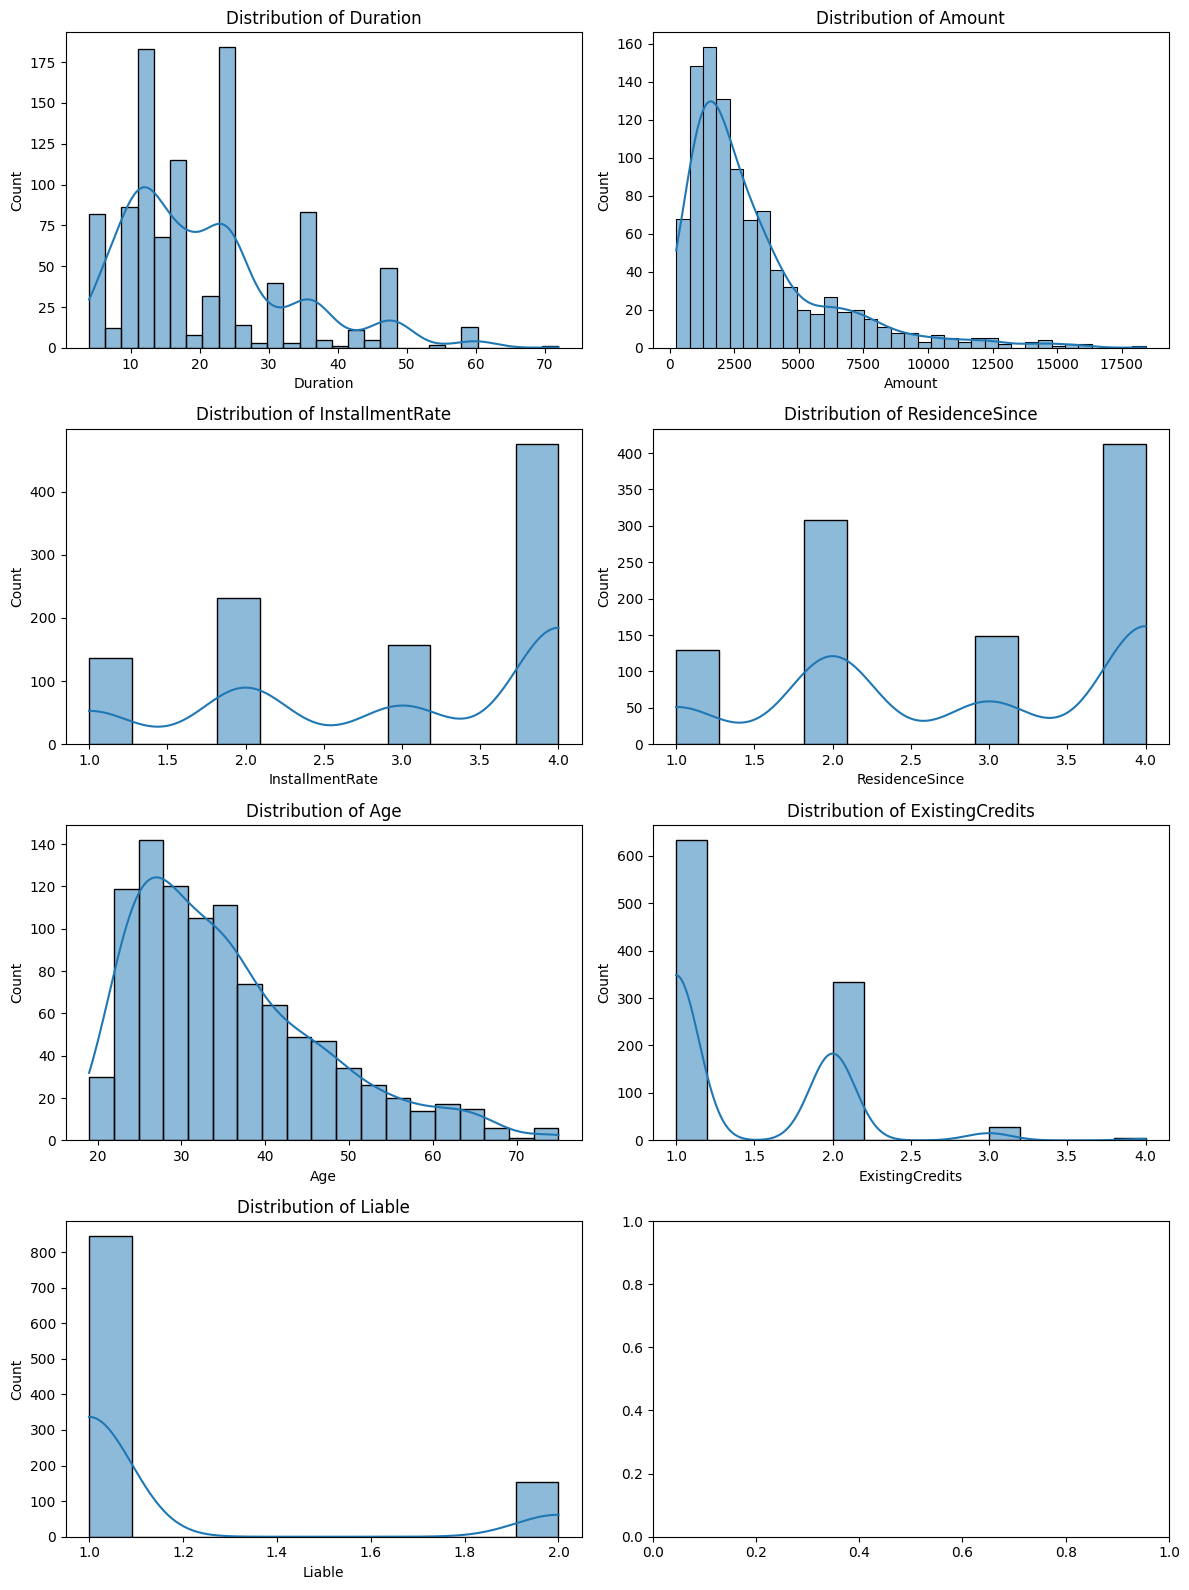

,count,mean,std,min,25%,50%,75%,max
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
InstallmentRate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
ResidenceSince,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
ExistingCredits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
Liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [5]:
num_cols = feature_num_cols.copy()
print(f'Numerical feature columns ({len(num_cols)}): {num_cols}')

if len(num_cols) == 0:
    print('Không có cột số để phân tích.')
else:

    # có 7 cột số, chia subplots thành 4 thàng, mỗi thàng 2 cột (trừ thằng cuối có 1 cột)
    n = len(num_cols)
    n_row = 4
    n_col = 2
    fig, axes = plt.subplots(n_row, n_col, figsize=(n_col * 6, n_row * 4))
    axes = axes.flatten()   
    for i, col in enumerate(num_cols):
        sns.histplot(eda_df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    display(eda_df[num_cols].describe().T)

## Phân tích biến phân loại (categorical)

Categorical feature columns (13): ['Status', 'History', 'Purpose', 'Savings', 'Employment', 'PersonalStatus', 'OtherDebtors', 'Property', 'OtherPlans', 'Housing', 'Job', 'Telephone', 'ForeignWorker']


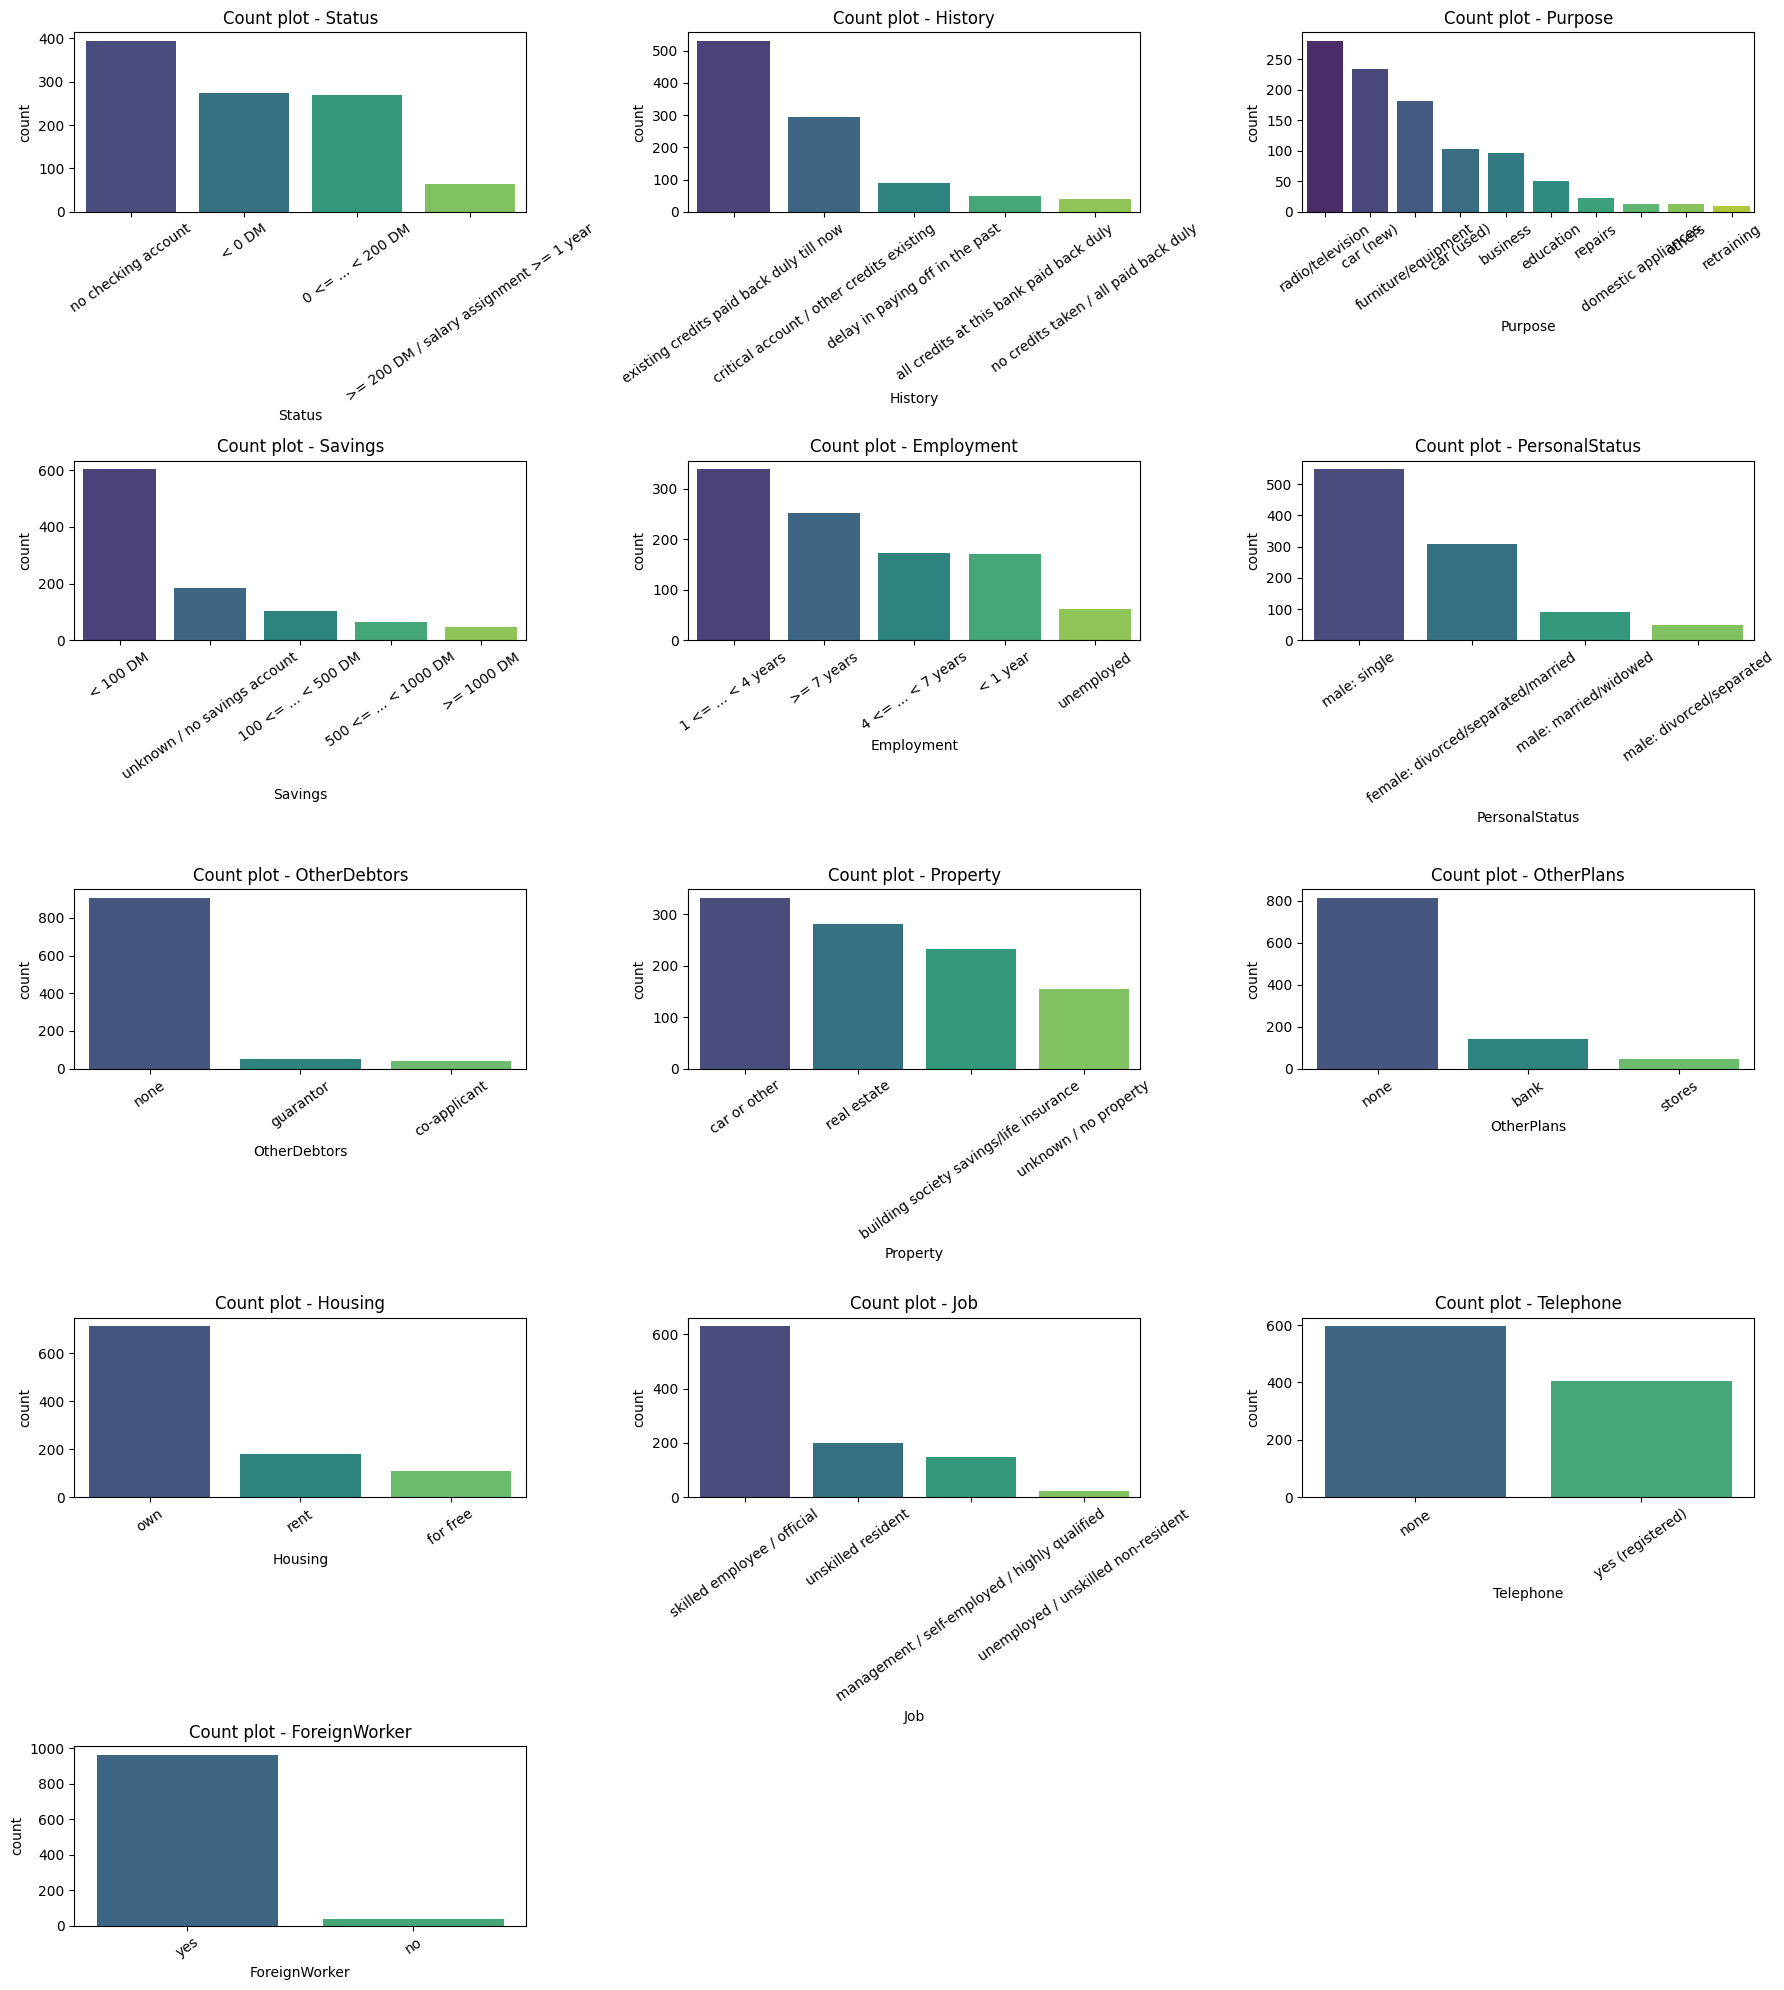


--- Status ---


Status
no checking account                        39.4
< 0 DM                                     27.4
0 <= ... < 200 DM                          26.9
>= 200 DM / salary assignment >= 1 year     6.3
Name: pct(%), dtype: float64


--- History ---


History
existing credits paid back duly till now     53.0
critical account / other credits existing    29.3
delay in paying off in the past               8.8
all credits at this bank paid back duly       4.9
no credits taken / all paid back duly         4.0
Name: pct(%), dtype: float64


--- Purpose ---


...

Job
skilled employee / official                      63.0
unskilled resident                               20.0
management / self-employed / highly qualified    14.8
unemployed / unskilled non-resident               2.2
Name: pct(%), dtype: float64


--- Telephone ---


Telephone
none                59.6
yes (registered)    40.4
Name: pct(%), dtype: float64


--- ForeignWorker ---


ForeignWorker
yes    96.3
no      3.7
Name: pct(%), dtype: float64

In [6]:
cat_cols = feature_cat_cols.copy()
print(f'Categorical feature columns ({len(cat_cols)}): {cat_cols}')

if len(cat_cols) == 0:
    print('Không có cột categorical để vẽ.')
else:
    n_cols_plot = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols_plot))
    fig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(18, 4 * n_rows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(cat_cols):
        order = eda_df[col].value_counts().index
        sns.countplot(data=eda_df, x=col, order=order, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Count plot - {col}')
        axes[i].tick_params(axis='x', rotation=35)

    for j in range(len(cat_cols), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    for col in cat_cols:
        print(f"\n--- {col} ---")
        display((eda_df[col].value_counts(normalize=True) * 100).round(2).rename('pct(%)'))

In [7]:
# xem xét độ chênh lệch giữa 2 lớp trong target
print(f"\nClass distribution in target '{target_col}':")
display((eda_df[target_col].value_counts(normalize=True) * 100).round(2).rename('pct(%)'))


Class distribution in target 'Class':


Class
good    70.0
bad     30.0
Name: pct(%), dtype: float64

## Phân tích mối quan hệ giữa biến

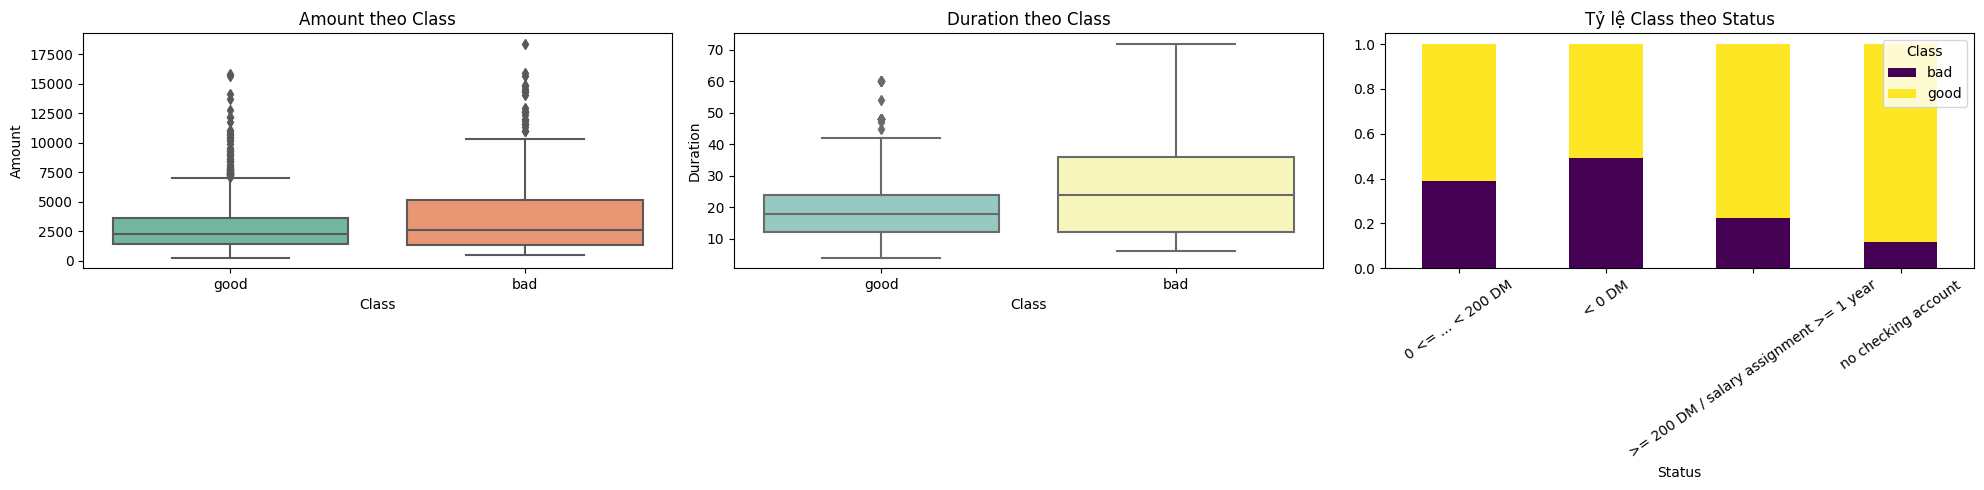

,Duration,Amount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Liable
Status,,,,,,,
0 <= ... < 200 DM,18.0,2622.0,3.0,3.0,31.0,1.0,1.0
< 0 DM,18.0,2353.5,4.0,3.0,32.0,1.0,1.0
no checking account,18.0,2248.0,3.0,3.0,34.5,1.0,1.0
>= 200 DM / salary assignment >= 1 year,15.0,1881.0,3.0,2.0,36.0,1.0,1.0


In [8]:
# Phân tích quan hệ feature với target
plot_num_candidates = [c for c in ['Amount', 'Duration', 'Age'] if c in num_cols]
plot_cat_candidates = [c for c in ['Status', 'Purpose', 'Housing', 'History'] if c in feature_cat_cols]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Amount theo Class (hoặc biến số đầu tiên khả dụng)
if len(plot_num_candidates) >= 1 and target_col in eda_df.columns:
    c1 = plot_num_candidates[0]
    sns.boxplot(data=eda_df, x=target_col, y=c1, ax=axes[0], palette='Set2')
    axes[0].set_title(f'{c1} theo {target_col}')
else:
    axes[0].axis('off')

# 2) Duration/Age theo Class
if len(plot_num_candidates) >= 2 and target_col in eda_df.columns:
    c2 = plot_num_candidates[1]
    sns.boxplot(data=eda_df, x=target_col, y=c2, ax=axes[1], palette='Set3')
    axes[1].set_title(f'{c2} theo {target_col}')
else:
    axes[1].axis('off')

# 3) Categorical tiêu biểu theo target
if len(plot_cat_candidates) >= 1 and target_col in eda_df.columns:
    c3 = plot_cat_candidates[0]
    ctab = pd.crosstab(eda_df[c3], eda_df[target_col], normalize='index')
    ctab.plot(kind='bar', stacked=True, ax=axes[2], colormap='viridis')
    axes[2].set_title(f'Tỷ lệ {target_col} theo {c3}')
    axes[2].tick_params(axis='x', rotation=35)
    axes[2].legend(title=target_col)
else:
    axes[2].axis('off')

plt.tight_layout()
plt.show()

# bảng tổng hợp median các biến số theo một categorical tiêu biểu
if len(plot_cat_candidates) >= 1 and len(num_cols) > 0:
    group_col = plot_cat_candidates[0]
    group_summary = eda_df.groupby(group_col)[num_cols].median().sort_values(num_cols[0], ascending=False)
    display(group_summary.head(10))

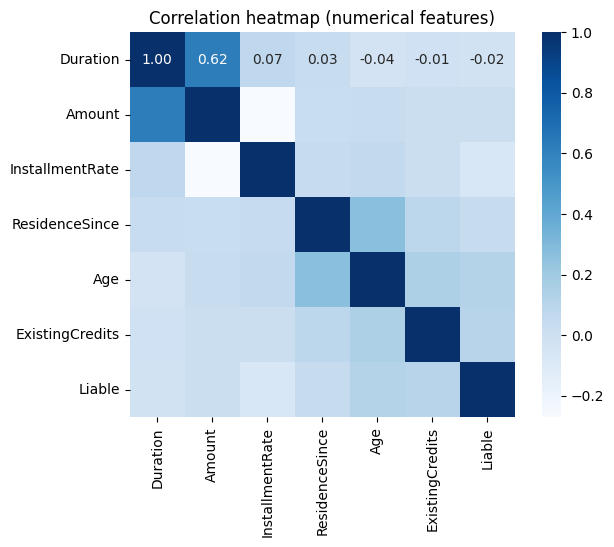

,Duration,Amount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Liable
Duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
Amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
InstallmentRate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
ResidenceSince,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
Age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
ExistingCredits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
Liable,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


In [9]:
# ma trận tương quan giữa các biến số
corr_cols = num_cols.copy()

if len(corr_cols) < 2:
    print('Không đủ cột số để tính tương quan.')
else:
    corr = eda_df[corr_cols].corr()

    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', square=True)
    plt.title('Correlation heatmap (numerical features)')
    plt.show()

    display(corr)

In [10]:
# phát hiện outlier cơ bản theo IQR cho biến số feature
outlier_summary = []
for col in num_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((eda_df[col] < lower) | (eda_df[col] > upper)).sum()
    outlier_summary.append({
        'feature': col,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'n_outliers': int(n_outliers),
        'outlier_pct(%)': round(n_outliers / len(eda_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct(%)', ascending=False)
display(outlier_df)

,feature,lower_bound,upper_bound,n_outliers,outlier_pct(%)
6,Liable,1.00,1.00,155,15.5
1,Amount,-2544.62,7882.38,72,7.2
0,Duration,-6.00,42.00,70,7.0
4,Age,4.50,64.50,23,2.3
5,ExistingCredits,-0.50,3.50,6,0.6
2,InstallmentRate,-1.00,7.00,0,0.0
3,ResidenceSince,-1.00,7.00,0,0.0


## Kết luận nhanh từ EDA (đã điều chỉnh cho dữ liệu UCI mới)

- 